# Notebook 01: Data Loading and Exploratory Data Analysis (EDA)

This notebook initializes the **Project 04** research pipeline by loading local mortality data from the **Human Mortality Database (HMD)**. 

### Research Scope:
- **Countries**: Switzerland (CHE), Sweden (SWE), Norway (NOR), West Germany (DEUTW), Netherlands (NLD), and Japan (JPN).
- **Objectives**: 
    - Parse raw HMD `.txt` files skipping metadata headers.
    - Standardize data formats for Age-Specific Mortality Rates ($m_x$) and Exposure to Risk ($E_x$).
    - Generate the **Figure 1** of the paper: A long-term comparative analysis of log-mortality across different demographic regimes.

## 1.1: Setup & Configuration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import warnings

# Add src to path to import style_config
sys.path.append('../src')
from style_config import set_style

warnings.filterwarnings("ignore")

# Initialize the professional style and get the country mapping
COUNTRIES = set_style()

# Path Configuration
RAW_DATA_DIR = "../data/raw/"
FIGURES_DIR = "../reports/figures/"
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Configuration complete using central style.")

Configuration complete using central style.


## 1.2: Local Data Parsing and Cleaning

In [5]:
def load_hmd_txt(country_code, file_type='mx'):
    """
    Parses locally downloaded HMD .txt files.
    file_type: 'mx' (Mortality Rates) or 'ex' (Exposures)
    """
    file_path = f"{RAW_DATA_DIR}{country_code}_{file_type}.txt"
    
    if not os.path.exists(file_path):
        print(f"Warning: File not found -> {file_path}")
        return None
    
    # HMD standard: Skip first 2 lines, whitespace separator, handle '.' as NaN
    df = pd.read_csv(file_path, sep='\s+', skiprows=2, na_values='.')
    
    # Structural Cleaning: Age '110+' to integer 110
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    
    # Type Cleaning: Ensure numeric types for all population columns
    for col in ['Female', 'Male', 'Total']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
    return df

# Process the cluster
for code in COUNTRIES.keys():
    for ftype in ['mx', 'ex']:
        df = load_hmd_txt(code, ftype)
        if df is not None:
            df.to_csv(f"{RAW_DATA_DIR}{code}_{ftype}_clean.csv", index=False)
            print(f"Cleaned and saved: {code} {ftype.upper()}")

Cleaned and saved: CHE MX
Cleaned and saved: CHE EX
Cleaned and saved: SWE MX
Cleaned and saved: SWE EX
Cleaned and saved: NOR MX
Cleaned and saved: NOR EX
Cleaned and saved: DEUTW MX
Cleaned and saved: DEUTW EX
Cleaned and saved: NLD MX
Cleaned and saved: NLD EX
Cleaned and saved: JPN MX
Cleaned and saved: JPN EX


## 1.3: EDA Visualization

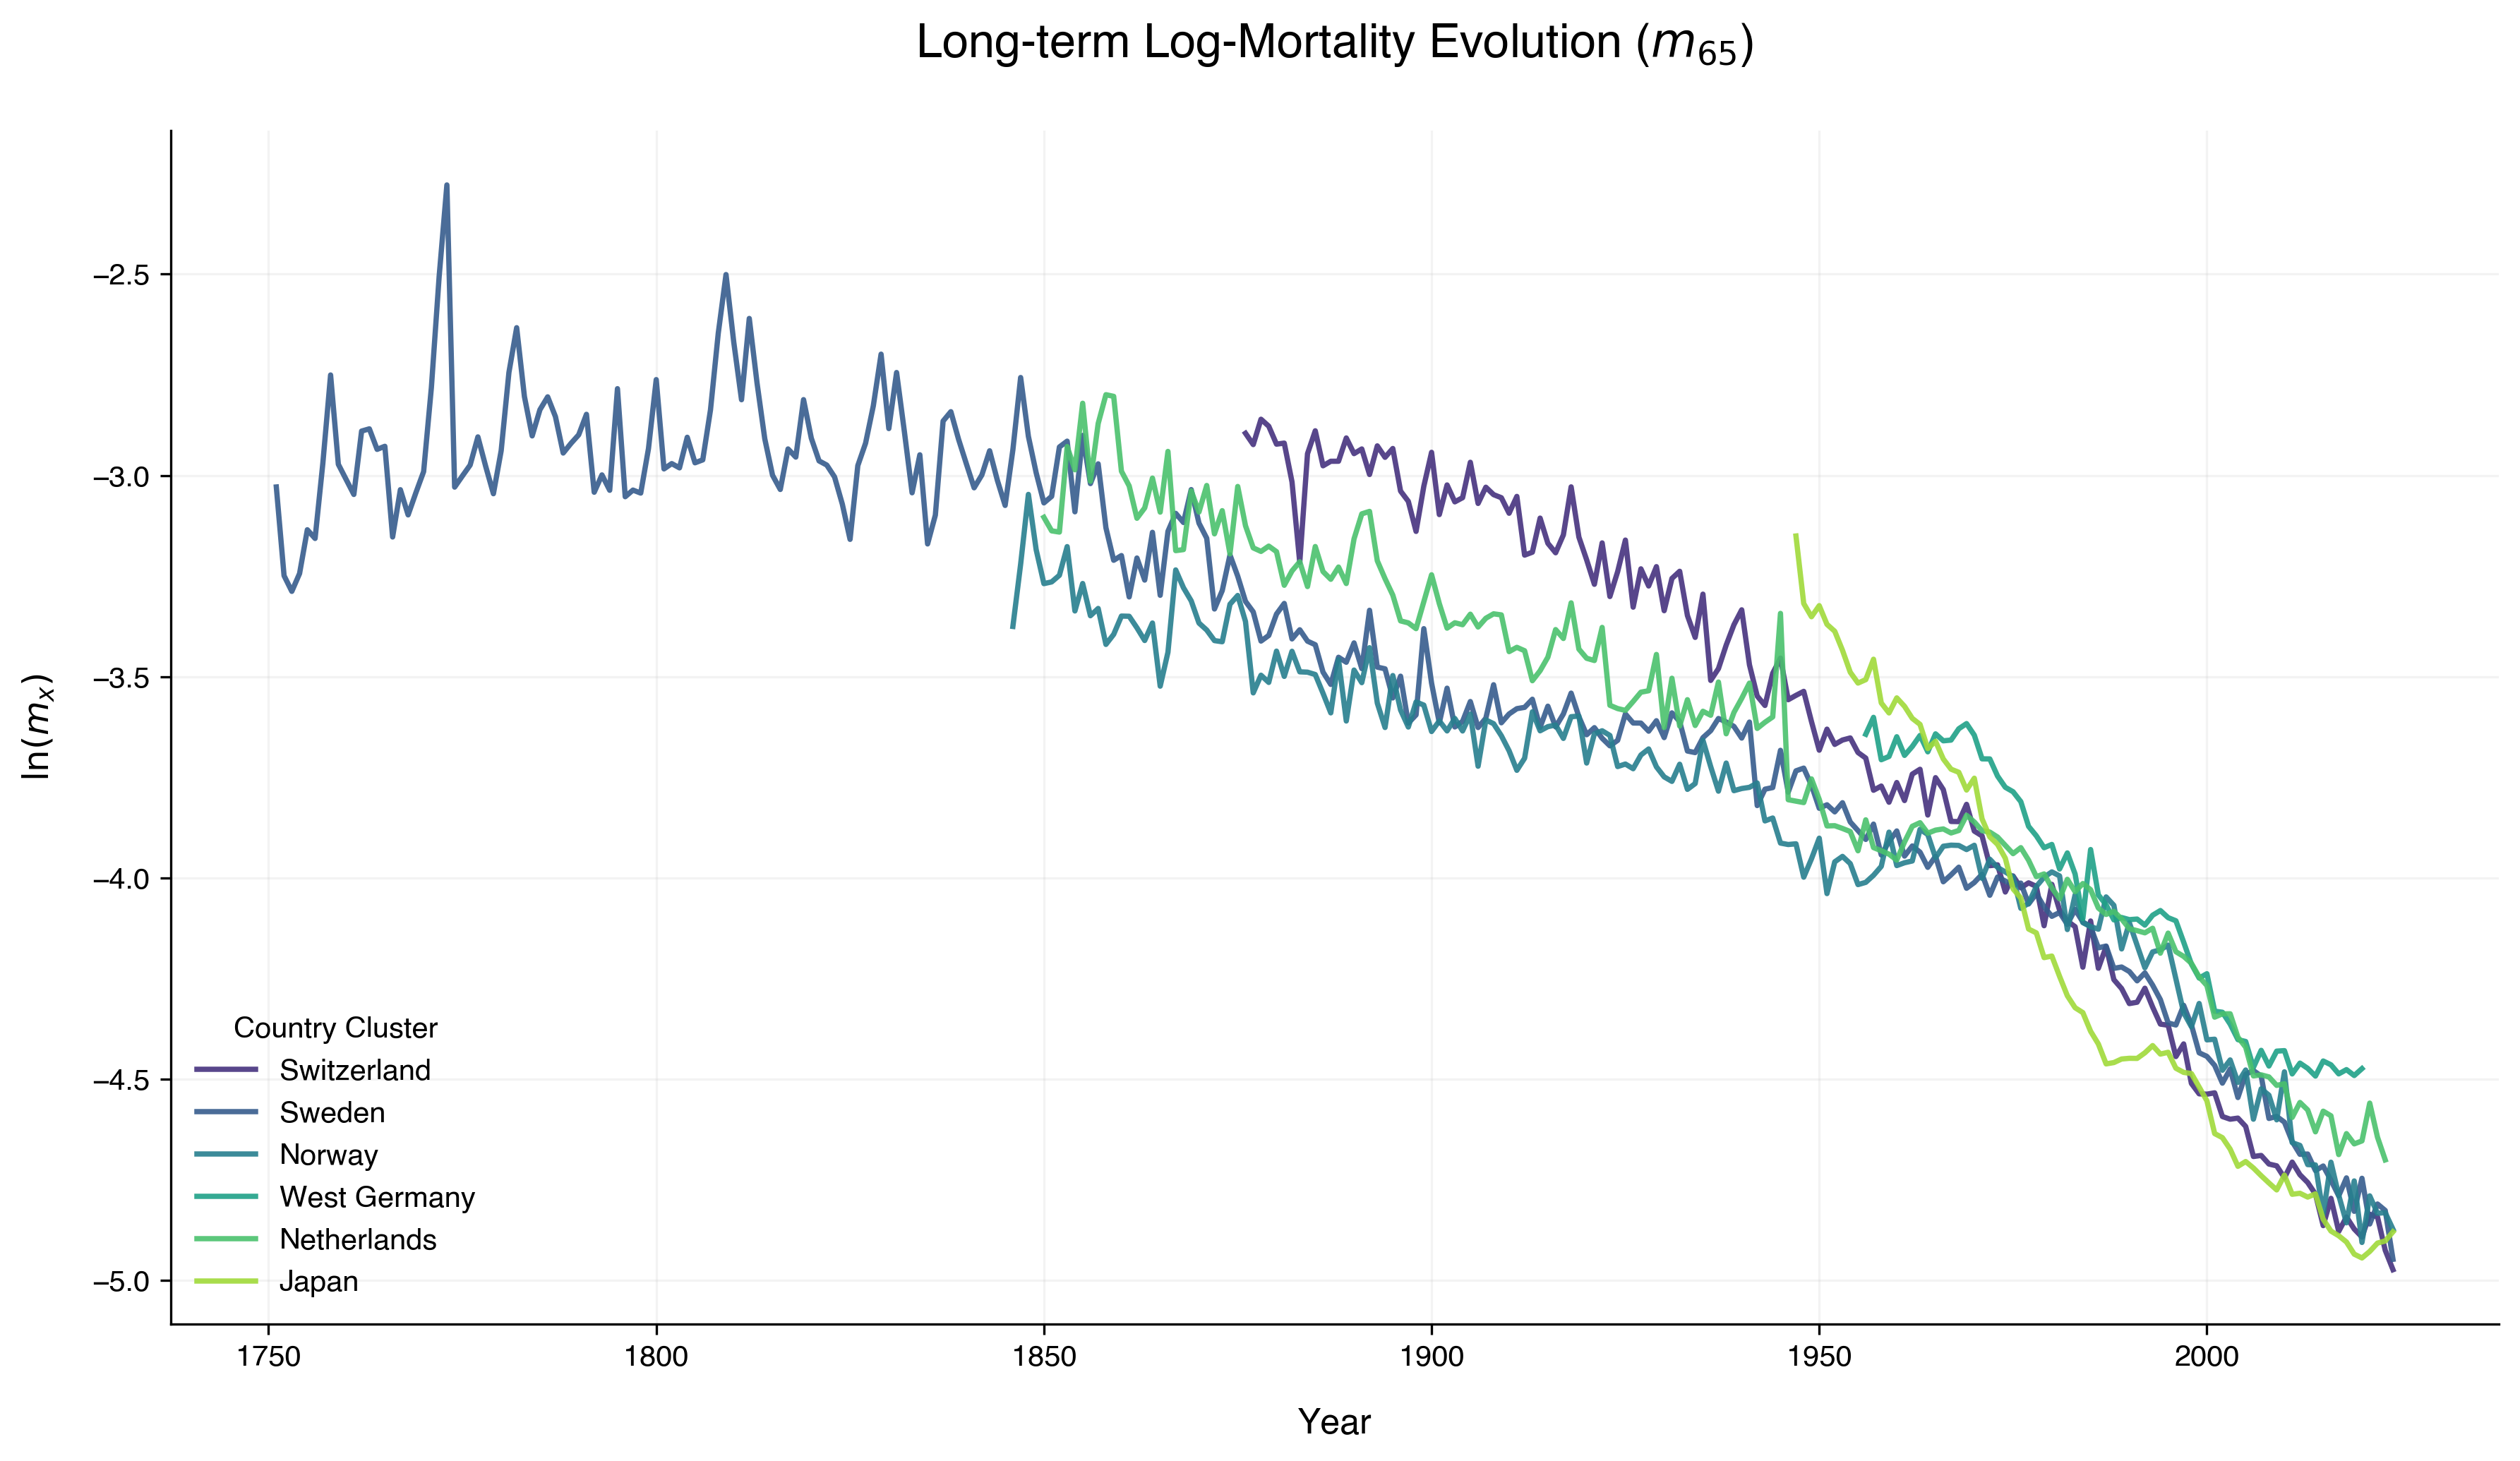

In [6]:
def generate_fig01_comparison(age=65):
    fig, ax = plt.subplots()
    
    for i, (code, name) in enumerate(COUNTRIES.items()):
        file_path = f"{RAW_DATA_DIR}{code}_mx_clean.csv"
        if os.path.exists(file_path):
            df = pd.read_csv(file_path)
            subset = df[df['Age'] == age].copy()
            
            if not subset.empty:
                ax.plot(subset['Year'], np.log(subset['Total']), 
                        label=name, 
                        linewidth=1.8, 
                        alpha=0.9)

    # Standardized labels and titles
    ax.set_title(f"Long-term Log-Mortality Evolution ($m_{{{age}}}$)", pad=25)
    ax.set_xlabel("Year", labelpad=12)
    ax.set_ylabel(r"$\ln(m_x)$", labelpad=12)
    
    ax.legend(title="Country Cluster", loc='lower left', frameon=False)
    plt.tight_layout()
    
    save_path = f"{FIGURES_DIR}fig01_comparison_age_{age}.png"
    plt.savefig(save_path)
    plt.show()

generate_fig01_comparison(age=65)